# IMPORTS

In [1]:
import os
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import librosa
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, f1_score, recall_score, precision_score, confusion_matrix, \
    classification_report
import soundfile as sf
from PIL import Image
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
import cv2
from sklearn.model_selection import GroupShuffleSplit
from tqdm import tqdm

# DATASET

## CREMA-D

### Load CREMA-D

In [2]:
dataset_folder = "dataset\\CREMA-D\\AudioWAV\\"

data = []

emotion_map = {
    "ANG": "Anger",
    "DIS": "Disgust",
    "FEA": "Fear",
    "HAP": "Happy",
    "NEU": "Neutral",
    "SAD": "Sad",
}

for file in os.listdir(dataset_folder):
    filename, _ = os.path.splitext(file)

    parts = filename.split("_")

    # Speaker
    speaker = parts[0]

    # Path
    path = os.path.join(dataset_folder, file)

    # Emotion
    emotion_code = parts[2]
    emotion = emotion_map.get(emotion_code, "Unknown")

    data.append([speaker, path, emotion])

dataset_df = pd.DataFrame(data, columns=["speaker", "path", "emotion"])
print(dataset_df.shape[0])

7442


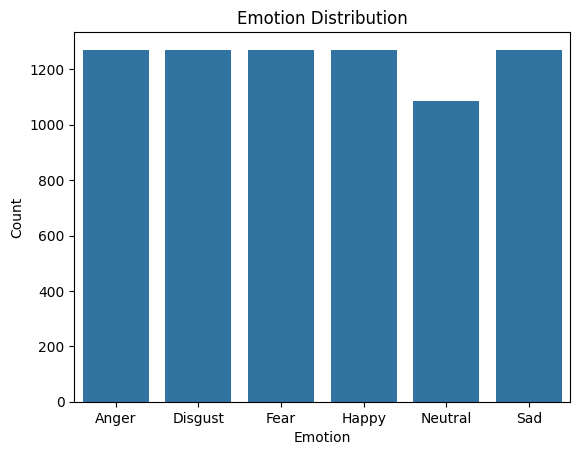

In [3]:
def check_distribution(df: pd.DataFrame, title):
    sns.countplot(x="emotion", data=df)
    plt.title(title)
    plt.xlabel("Emotion")
    plt.ylabel("Count")
    plt.show()


check_distribution(dataset_df, "Emotion Distribution")

In [4]:
def create_csv(df: pd.DataFrame, output_csv: str):
    df.to_csv(output_csv, index=False)


os.makedirs("CSVs", exist_ok=True)

In [5]:
create_csv(dataset_df, "CSVs\\dataset.csv")

### Remove silence

In [6]:
SILENCE_TOP_DB = 30

MIN_DURATION_SEC = 0.3

OUTPUT_DIR = "dataset_silenced/"
os.makedirs(OUTPUT_DIR, exist_ok=True)

errors = 0
skipped_too_short = 0
file_data = []

progress = tqdm(
    dataset_df.iterrows(),
    total=len(dataset_df),
    desc="Removing silence"
)

for idx, row in progress:
    original_stem = os.path.splitext(os.path.basename(row["path"]))[0]
    output_path = os.path.join(OUTPUT_DIR, f"{original_stem}.wav")

    try:
        y, sr = librosa.load(row["path"], sr=None, mono=True)
    except Exception as e:
        progress.write(f"[ERROR] Cannot read file: {row['path']} - {e}")
        errors += 1
        continue

    y_trimmed, _ = librosa.effects.trim(y, top_db=SILENCE_TOP_DB)

    trimmed_duration = len(y_trimmed) / sr

    if trimmed_duration >= MIN_DURATION_SEC:
        sf.write(output_path, y_trimmed, sr)
    else:
        sf.write(output_path, y, sr)
        skipped_too_short += 1
        progress.write(f"[WARNING] Skipping too short: {trimmed_duration:.3f}s, keep original: {row['path']}")

    file_data.append({
        "speaker": row["speaker"],
        "path": output_path,
        "emotion": row["emotion"]
    })

total = len(dataset_df)
trimmed_ok = len(file_data) - skipped_too_short

print(f"Files to process  : {total}")
print(f"Trimmed           : {trimmed_ok}")
print(f"Kept original     : {skipped_too_short}")
print(f"Errors            : {errors}")

dataset_silenced = pd.DataFrame(file_data)
create_csv(dataset_silenced, "CSVs\\dataset_silenced.csv")

Removing silence: 100%|██████████| 7442/7442 [00:29<00:00, 251.19it/s]

Files to process  : 7442
Trimmed           : 7442
Kept original     : 0
Errors            : 0


### Split dataset

Train :  5890 samples (79.1%)
Val   :   732 samples (9.8%)
Test  :   820 samples (11.0%)


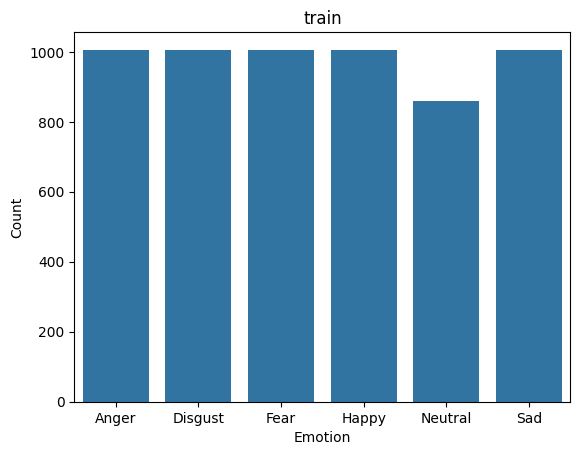

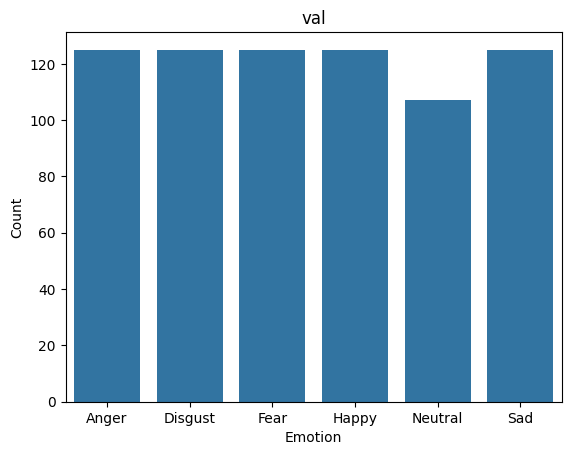

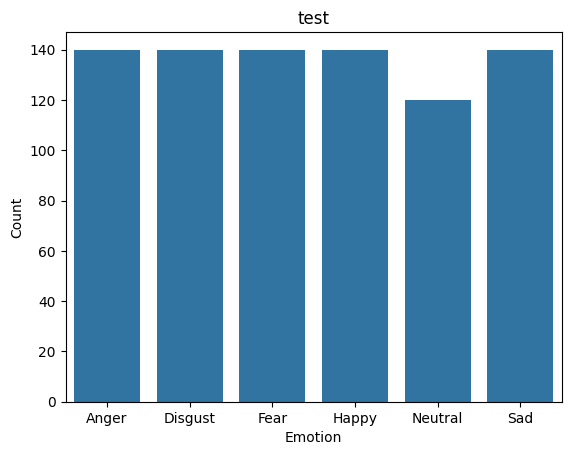

In [8]:
TRAIN_RATIO = 0.8
TEMP_RATIO = 1 - TRAIN_RATIO
RANDOM_STATE = 42

dataset_silenced = pd.read_csv("CSVs\\dataset_silenced.csv")

assert len(dataset_silenced) > 0, "dataset_silenced empty, run remove silence first"

# Split 1: train - temp (val + test)
gss_train = GroupShuffleSplit(
    test_size=TEMP_RATIO,
    n_splits=1,
    random_state=RANDOM_STATE
)

train_idx, temp_idx = next(
    gss_train.split(
        dataset_silenced,
        groups=dataset_silenced["speaker"]
    )
)

# Split 2: val - test
temp_subset = dataset_silenced.iloc[temp_idx]

gss_val = GroupShuffleSplit(
    test_size=0.5,
    n_splits=1,
    random_state=RANDOM_STATE
)

val_idx, test_idx = next(
    gss_val.split(
        temp_subset,
        groups=temp_subset["speaker"]
    )
)

train_df = dataset_silenced.iloc[train_idx].reset_index(drop=True)
val_df = temp_subset.iloc[val_idx].reset_index(drop=True)
test_df = temp_subset.iloc[test_idx].reset_index(drop=True)

print(f"Train : {len(train_df):>5} samples ({len(train_df) / len(dataset_silenced) * 100:.1f}%)")
print(f"Val   : {len(val_df):>5} samples ({len(val_df) / len(dataset_silenced) * 100:.1f}%)")
print(f"Test  : {len(test_df):>5} samples ({len(test_df) / len(dataset_silenced) * 100:.1f}%)")

os.makedirs("CSVs", exist_ok=True)
create_csv(train_df, "CSVs\\train.csv")
create_csv(val_df, "CSVs\\val.csv")
create_csv(test_df, "CSVs\\test.csv")

for name, df in [("train", train_df), ("val", val_df), ("test", test_df)]:
    check_distribution(df, name)

# CONVERT TO MEL SPECTROGRAM

## Config

In [ ]:
TARGET_SR       = 22050   # resample về sr cố định để spectrogram nhất quán
TARGET_DURATION = 3.0     # giây — pad/trim tất cả audio về cùng độ dài
TARGET_SAMPLES  = int(TARGET_SR * TARGET_DURATION)  # 66 150 samples

N_MELS     = 128
N_FFT      = 1024
HOP_LENGTH = 256
IMG_SIZE   = 224

SPECTROGRAM_DIR = "features/images/"
FEATURES_DIR    = "features/"
os.makedirs(SPECTROGRAM_DIR, exist_ok=True)
os.makedirs(FEATURES_DIR,    exist_ok=True)

train_df = pd.read_csv("CSVs/train.csv")
val_df   = pd.read_csv("CSVs/val.csv")
test_df  = pd.read_csv("CSVs/test.csv")

## Run

In [ ]:
def pad_or_trim(y: np.ndarray, target_samples: int) -> np.ndarray:
    """Trim nếu quá dài, zero-pad ở cuối nếu quá ngắn."""
    if len(y) > target_samples:
        return y[:target_samples]
    if len(y) < target_samples:
        return np.pad(y, (0, target_samples - len(y)))
    return y


def graph_spectrogram(audio_path: str, output_path: str) -> None:
    y, sr = librosa.load(audio_path, sr=TARGET_SR, mono=True)

    # normalize duration trước khi tạo spectrogram
    y = pad_or_trim(y, TARGET_SAMPLES)

    mel = librosa.feature.melspectrogram(
        y=y, sr=sr, n_mels=N_MELS, n_fft=N_FFT, hop_length=HOP_LENGTH
    )
    mel_db = librosa.power_to_db(mel, ref=np.max)

    fig, ax = plt.subplots(1)
    fig.set_size_inches(IMG_SIZE / 100, IMG_SIZE / 100)
    fig.subplots_adjust(left=0, right=1, bottom=0, top=1)
    ax.axis("off")
    librosa.display.specshow(mel_db, sr=sr, hop_length=HOP_LENGTH, ax=ax, cmap="viridis")
    fig.savefig(output_path, dpi=100)
    plt.close(fig)


def prepare_images(df: pd.DataFrame, split_name: str) -> None:
    data   = []
    labels = []
    errors = 0

    bar = tqdm(df.iterrows(), total=len(df), desc=f"Processing {split_name}")
    for idx, row in bar:
        img_path = os.path.join(SPECTROGRAM_DIR, f"{split_name}_{idx}.png")

        if not os.path.exists(img_path):
            try:
                graph_spectrogram(row["path"], img_path)
            except Exception as e:
                bar.write(f"[ERROR] {row['path']}: {e}")
                errors += 1
                continue

        image = cv2.imread(img_path, cv2.IMREAD_COLOR)
        if image is None:
            bar.write(f"[ERROR] Không đọc được ảnh: {img_path}")
            errors += 1
            continue

        data.append(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
        labels.append(row["emotion"])

    np.save(os.path.join(FEATURES_DIR, f"{split_name}_images_data.npy"),
            np.array(data, dtype=np.uint8))
    np.save(os.path.join(FEATURES_DIR, f"{split_name}_images_labels.npy"),
            np.array(labels))

    print(f"[{split_name}] Saved {len(data)} images — errors: {errors}")


prepare_images(train_df, "train")
prepare_images(val_df,   "val")
prepare_images(test_df,  "test")

# DATA LOADER

## Unload processed spetrogram images

In [ ]:
x_trainI = np.load('features\\train_images_data.npy')
x_validationI = np.load('features\\val_images_data.npy')
x_testI = np.load('features\\test_images_data.npy')

Labels_train = np.load('features\\train_images_labels.npy')
Labels_val= np.load('features\\val_images_labels.npy')
Labels_test = np.load('features\\test_images_labels.npy')

encoder = LabelEncoder()
y_trainI = encoder.fit_transform(Labels_train)
y_validationI = encoder.transform(Labels_val)
y_testI = encoder.transform(Labels_test)

print(x_trainI.shape)
print(x_validationI.shape)
print(x_testI.shape)
print(y_trainI.shape)
print(y_validationI.shape)
print(y_testI.shape)

print(encoder.classes_)

## Data loader

In [ ]:
class EmotionDataset(Dataset):
    def __init__(self, images, labels, transform=None):
        self.images = images
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        image = self.images[idx]
        label = int(self.labels[idx])

        # convert numpy array to PIL Image
        image = Image.fromarray(image)

        if self.transform is not None:
            image = self.transform(image)

        # convert label to tensor long type
        label = torch.tensor(label, dtype=torch.long)

        return image, label

In [ ]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

BATCH_SIZE = 8
NUM_WORKERS = 0

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=IMAGENET_MEAN,
        std=IMAGENET_STD
    )
])

eval_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=IMAGENET_MEAN,
        std=IMAGENET_STD
    )
])

# Datasets
train_dataset = EmotionDataset(
    images=x_trainI,
    labels=y_trainI,
    transform=train_transform
)

val_dataset = EmotionDataset(
    images=x_validationI,
    labels=y_validationI,
    transform=eval_transform
)

test_dataset = EmotionDataset(
    images=x_testI,
    labels=y_testI,
    transform=eval_transform
)

# DataLoaders
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available()
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available()
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available()
)

# map
dataloaders = {
    "train": train_loader,
    "val": val_loader,
    "test": test_loader
}

dataset_sizes = {
    "train": len(train_dataset),
    "val": len(val_dataset),
    "test": len(test_dataset)
}

print(f"Train loader size: {len(train_loader)}")
print(f"Validation loader size: {len(val_loader)}")
print(f"Test loader size: {len(test_loader)}")


# MODEL

## ResNet18

In [10]:
class BuildResnet(nn.Module):
    def __init__(self, num_classes):
        super(BuildResnet, self).__init__()

        self.model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

        for param in self.model.parameters():
            param.requires_grad = False

        for layer in [self.model.layer4]:
            for param in layer.parameters():
                param.requires_grad = True

        self.model.fc = nn.Sequential(  # type: ignore
            nn.Linear(self.model.fc.in_features, 256),
            nn.ReLU(),
            nn.Dropout(0.6),
            nn.Linear(256, num_classes),
        )

    def forward(self, x):
        return self.model(x)


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
ResNet = BuildResnet(num_classes=6).to(device)

criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

optimizer = optim.AdamW([
    {"params": ResNet.model.layer4.parameters(), "lr": 1e-5},
    {"params": ResNet.model.fc.parameters(), "lr": 5e-5},
], weight_decay=5e-4)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="min", factor=0.5, patience=5
)

print(f"Using device: {device}")

print(ResNet)

Using device: cuda
BuildResnet(
  (model): ResNet(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, a

## DenseNet121

In [ ]:
class BuildDensenet(nn.Module):
    def __init__(self, num_classes):
        super(BuildDensenet, self).__init__()

        self.model = models.densenet121(weights=models.DenseNet121_Weights.DEFAULT)

        for param in self.model.parameters():
            param.requires_grad = False

        for param in self.model.features.denseblock4.parameters():  # type: ignore
            param.requires_grad = True

        for param in self.model.features.norm5.parameters():  # type: ignore
            param.requires_grad = True

        self.model.classifier = nn.Sequential(
            nn.Linear(self.model.classifier.in_features, 256),
            nn.ReLU(),
            nn.Dropout(0.6),
            nn.Linear(256, num_classes),
        )

    def forward(self, x):
        return self.model(x)


device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
DenseNet = BuildDensenet(num_classes=6).to(device)

criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

optimizer = optim.AdamW(
    [
        {"params": DenseNet.model.features.denseblock4.parameters(), "lr": 1e-5},  # type: ignore
        {"params": DenseNet.model.classifier.parameters(), "lr": 5e-5},  # type: ignore
    ],
    weight_decay=5e-4,
)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="min", factor=0.5, patience=5
)

print(f"Using device: {device}")
print(DenseNet)

## VGG16

In [ ]:
class BuildVgg(nn.Module):
    def __init__(self, num_classes):
        super(BuildVgg, self).__init__()

        self.model = models.vgg16(weights=models.VGG16_Weights.DEFAULT)

        for param in self.model.parameters():
            param.requires_grad = False

        for layer in self.model.features[24:]:  # type: ignore
            for param in layer.parameters():
                param.requires_grad = True

        self.model.classifier = nn.Sequential(
            nn.Linear(512 * 7 * 7, 4096),
            nn.ReLU(True),
            nn.Dropout(0.6),
            nn.Linear(4096, 4096),
            nn.ReLU(True),
            nn.Dropout(0.6),
            nn.Linear(4096, num_classes),
        )

    def forward(self, x):
        return self.model(x)


device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
VGG = BuildVgg(num_classes=6).to(device)

criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

optimizer = optim.AdamW(
    [
        {"params": VGG.model.features[24:].parameters(), "lr": 1e-5},  # type: ignore
        {"params": VGG.model.classifier.parameters(), "lr": 5e-5},  # type: ignore
    ],
    weight_decay=5e-4,
)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="min", factor=0.5, patience=5
)

print(f"Using device: {device}")
print(VGG)

# TRAIN / VALIDATE / TEST

## Train & Validate

In [19]:
EPOCHS = 30
PATIENCE = 5

best_val_loss = float("inf")
best_epoch = 0
counter = 0

history = {
    "train_loss": [],
    "train_acc": [],
    "train_f1": [],
    "train_recall": [],
    "train_precision": [],
    "val_loss": [],
    "val_acc": [],
    "val_f1": [],
    "val_recall": [],
    "val_precision": [],
}

MODEL = ResNet

for epoch in range(EPOCHS):
    # ==========================
    # TRAIN
    # ==========================
    MODEL.train()

    train_labels_all = []
    train_preds_all = []
    running_loss = 0
    train_total = 0

    tqdm_loader = tqdm(
        train_loader, desc=f"Epoch {epoch + 1}/{EPOCHS} - Training", leave=False
    )
    for images, labels in tqdm_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = MODEL(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        batch_size = images.size(0)
        running_loss += loss.item() * batch_size
        train_total += batch_size

        preds = torch.argmax(outputs, dim=1)
        train_labels_all.extend(labels.cpu().numpy())
        train_preds_all.extend(preds.cpu().numpy())

    train_loss = running_loss / train_total
    train_acc = accuracy_score(train_labels_all, train_preds_all)
    train_f1 = f1_score(train_labels_all, train_preds_all, average="weighted")
    train_recall = recall_score(
        train_labels_all, train_preds_all, average="weighted", zero_division=0
    )
    train_precision = precision_score(
        train_labels_all, train_preds_all, average="weighted", zero_division=0
    )

    # ==========================
    # VALIDATION
    # ==========================
    MODEL.eval()
    val_labels_all = []
    val_preds_all = []
    val_running_loss = 0
    val_total = 0

    with torch.no_grad():
        for images, labels in tqdm(
                val_loader, desc=f"Epoch {epoch + 1}/{EPOCHS} - Validation", leave=False
        ):
            images = images.to(device)
            labels = labels.to(device)

            outputs = MODEL(images)
            loss = criterion(outputs, labels)

            batch_size = images.size(0)
            val_running_loss += loss.item() * batch_size
            val_total += batch_size

            preds = torch.argmax(outputs, dim=1)
            val_labels_all.extend(labels.cpu().numpy())
            val_preds_all.extend(preds.cpu().numpy())

    val_loss = val_running_loss / val_total
    val_acc = accuracy_score(val_labels_all, val_preds_all)
    val_f1 = f1_score(val_labels_all, val_preds_all, average="weighted")
    val_recall = recall_score(
        val_labels_all, val_preds_all, average="weighted", zero_division=0
    )
    val_precision = precision_score(
        val_labels_all, val_preds_all, average="weighted", zero_division=0
    )

    scheduler.step(val_loss)

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["train_f1"].append(train_f1)
    history["train_recall"].append(train_recall)
    history["train_precision"].append(train_precision)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)
    history["val_f1"].append(val_f1)
    history["val_recall"].append(val_recall)
    history["val_precision"].append(val_precision)

    print(f"Epoch {epoch + 1}/{EPOCHS}")
    print(
        f"Train | Loss: {train_loss:.4f} | Acc: {train_acc:.4f} | F1: {train_f1:.4f} | Recall: {train_recall:.4f} | Precision: {train_precision:.4f}"
    )
    print(
        f"Val   | Loss: {val_loss:.4f} | Acc: {val_acc:.4f} | F1: {val_f1:.4f} | Recall: {val_recall:.4f} | Precision: {val_precision:.4f}"
    )
    # In lr của từng group để theo dõi
    for i, pg in enumerate(optimizer.param_groups):
        print(f"LR group {i}: {pg['lr']:.2e}")

    # ==========================
    # EARLY STOPPING & SAVE BEST MODEL
    # ==========================
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_epoch = epoch + 1
        counter = 0
        torch.save(MODEL.state_dict(), f"{MODEL._get_name()}.pth")
        print("--> New Best Model Saved!")
    else:
        counter += 1
        if counter >= PATIENCE:
            print("Early stopping triggered.")
            break

# ==========================
# RESTORE BEST WEIGHTS
# ==========================
MODEL.load_state_dict(
    torch.load(f"{MODEL._get_name()}.pth", map_location=device, weights_only=True)
)
print(f"Best epoch: {best_epoch}")

KeyboardInterrupt: 

In [ ]:
# Plot training history
fig, axes = plt.subplots(1, 3, figsize=(21, 5))

# Loss plot
axes[0].plot(history['train_loss'], label='Train Loss', marker='o', linewidth=2)
axes[0].plot(history['val_loss'], label='Validation Loss', marker='o', linewidth=2)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training and Validation Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy plot
axes[1].plot(history['train_acc'], label='Train Accuracy', marker='o', linewidth=2)
axes[1].plot(history['val_acc'], label='Validation Accuracy', marker='o', linewidth=2)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Training and Validation Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

axes[2].plot(history['train_f1'], label='Train F1 Score', marker='o', linewidth=2)
axes[2].plot(history['val_f1'], label='Validation F1 Score', marker='o', linewidth=2)
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('F1 Score')
axes[2].set_title('Training and Validation F1 Score')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Test

In [ ]:
# Helper to evaluate model on a dataloader
def evaluate_model(model, loader, device=device):
    model.eval()
    true_labels = []
    predicted_labels = []
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)
            outputs = model(images)
            preds = torch.argmax(outputs, dim=1)
            predicted_labels.extend(preds.cpu().numpy().tolist())
            true_labels.extend(labels.cpu().numpy().tolist())
    return true_labels, predicted_labels


# Evaluate on the test set
print("\nEvaluating on test set...")
true_labels, predicted_labels = evaluate_model(MODEL, test_loader)

# Classification Report
print("Classification Report (Test):")
print(classification_report(true_labels, predicted_labels, target_names=emotion_list))

# Confusion Matrix
cm = confusion_matrix(true_labels, predicted_labels)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=emotion_list, yticklabels=emotion_list)
plt.title("Confusion Matrix (Test)")
plt.ylabel("Actual Labels")
plt.xlabel("Predicted Labels")
plt.show()